# Drop Zone Defect Detector — 2-Stage Pipeline

## Stage 1 — Detection (EfficientNet B0)
"Is this photo the inside of an ice bin / drop zone?"
→ NO  → NOISE (skip)
→ YES → Stage 2

## Stage 2 — Quality (DINOv2 + Isolation Forest)
"Is this drop zone GOOD or a manufacturing DEFECT?"
→ GOOD / DEFECT / UNCERTAIN

## Drive folder structure
```
MyDrive/
  drop_zone_training/
    good/           ← normal drop zone photos
    bad/            ← manufacturing defect photos (caulking, rough edges, assembly)
    noise/  ← any photo that is NOT the inside of the bin
                      (cube separator photos, exterior, data plates, etc.)
    trained_models/ ← both models saved here
```

## Steps
1. Runtime → Change runtime type → **T4 GPU**
2. Add photos to all three Drive folders
3. Run all cells top to bottom
4. Download both model files at the end

In [ ]:
# Cell 1 — Imports
!pip install --upgrade torch torchvision
import pickle, shutil, random
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

IMG_SIZE = 224  # EfficientNet B0

INFERENCE_TF = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

DINO_TF = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

Device: cuda


In [ ]:
# Cell 2 — Mount Google Drive and load photo folders
from google.colab import drive
from pathlib import Path
from PIL import Image # Import Image to verify files

try:
    drive.mount('/content/drive')
    # If mount is successful, use the Drive path
    DRIVE_BASE = Path('/content/drive/MyDrive/drop_zone_training')
    print("Google Drive mounted successfully. Using Drive for data.")
except ValueError as e:
    print(f"Warning: Google Drive mount failed ({e}).")
    print("Attempting to use local extracted data. Please ensure cell 00b8e33c (unzipping) has been run.")
    # Fallback to local extracted path from cell 00b8e33c
    DRIVE_BASE = Path('/content/drop_zone_training')

# Ensure the base directory exists, whether from Drive or local
if not DRIVE_BASE.exists():
    if DRIVE_BASE == Path('/content/drive/MyDrive/drop_zone_training'):
        raise FileNotFoundError(
            f"Expected data directory '{DRIVE_BASE}' not found in Google Drive. "
            "Please check if 'drop_zone_training' folder exists in your MyDrive or ensure Drive is mounted correctly."
        )
    else: # Fallback path
        raise FileNotFoundError(
            f"Expected data directory '{DRIVE_BASE}' not found locally. "
            "Please ensure cell 00b8e33c has been run to extract data." # User-friendly message
        )

GOOD_DIR    = DRIVE_BASE / 'good'
BAD_DIR     = DRIVE_BASE / 'bad'
NOT_DZ_DIR  = DRIVE_BASE / 'noise'
MODEL_OUT   = DRIVE_BASE / 'trained_models'
MODEL_OUT.mkdir(parents=True, exist_ok=True)

def load_images(folder: Path, label: str) -> list[Path]:
    if not folder.exists():
        raise FileNotFoundError(f'Folder not found: {folder}')

    valid_paths = []
    all_files = list(folder.rglob('*'))

    for p in all_files:
        if p.suffix.lower() in ('.jpg', '.jpeg', '.png'):
            try:
                # Attempt to open and verify the image file
                img = Image.open(p)
                img.verify() # Verify that it is an image
                img.close()  # Close the image to release file handle
                valid_paths.append(p)
            except Exception as e:
                print(f"  [SKIPPING] Corrupted or invalid image: {p} - {e}")
        else:
            # Optionally skip non-image files more explicitly
            pass

    print(f'  {label}: {len(valid_paths)} photos (skipped {len(all_files) - len(valid_paths)} invalid/non-image files)')
    return valid_paths

print(f'Loading from: {DRIVE_BASE}\n')
good_paths   = load_images(GOOD_DIR,   'good (drop zone — normal)')
bad_paths    = load_images(BAD_DIR,    'bad  (drop zone — defect)')
not_dz_paths = load_images(NOT_DZ_DIR, 'noise')

if len(good_paths) < 10:
    raise RuntimeError(f'Only {len(good_paths)} good photos — need at least 10')
if len(bad_paths) == 0:
    raise RuntimeError('No bad photos found')
if len(not_dz_paths) < 10:
    raise RuntimeError(f'Only {len(not_dz_paths)} noise photos — add more')

print(f'\nTotal positives (Stage 1): {len(good_paths) + len(bad_paths)}')
print(f'Total negatives (Stage 1): {len(not_dz_paths)}')


Mounted at /content/drive
Google Drive mounted successfully. Using Drive for data.
Loading from: /content/drive/MyDrive/drop_zone_training

  good (drop zone — normal): 282 photos (skipped 0 invalid/non-image files)
  bad  (drop zone — defect): 31 photos (skipped 0 invalid/non-image files)
  [SKIPPING] Corrupted or invalid image: /content/drive/MyDrive/drop_zone_training/noise/KM-2600_QRSF73173_v389015_01838_photo.jpg - cannot identify image file '/content/drive/MyDrive/drop_zone_training/noise/KM-2600_QRSF73173_v389015_01838_photo.jpg'
  noise: 2295 photos (skipped 1 invalid/non-image files)

Total positives (Stage 1): 313
Total negatives (Stage 1): 2295


In [ ]:
import zipfile
import os
import shutil

zip_path = '/content/drive/MyDrive/drop_zone_training.zip'
extract_dir = '/content/drop_zone_training'
local_zip_path = '/content/drop_zone_training.zip'

# Copy the zip file from Drive to local Colab filesystem first
print(f'Copying {zip_path} to {local_zip_path}...')
shutil.copy(zip_path, local_zip_path)
print("Copy complete.")

os.makedirs(extract_dir, exist_ok=True)

print(f'Unzipping {local_zip_path} to {extract_dir}...')

with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipping complete.")

Copying /content/drive/MyDrive/drop_zone_training.zip to /content/drop_zone_training.zip...
Copy complete.
Unzipping /content/drop_zone_training.zip to /content/drop_zone_training...
Unzipping complete.


In [ ]:
# Cell 3 — Build Stage 1 detection dataset (optimized)
from pathlib import Path
import shutil
import random
from collections import defaultdict

DETECT_ROOT = Path('/content/dz_detect_split')

# --- Wipe and rebuild cleanly on re-runs ---
if DETECT_ROOT.exists():
    shutil.rmtree(DETECT_ROOT)

for split in ('train', 'val'):
    for cls in ('drop_zone', 'noise'):
        (DETECT_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

random.seed(42)

# --- Collision-safe copy: disambiguates by parent dir if names clash ---
def copy_image(src: Path, dst_dir: Path):
    dst = dst_dir / src.name
    if dst.exists():
        dst = dst_dir / f"{src.stem}__{src.parent.name}{src.suffix}"
    try:
        shutil.copy2(src, dst)
    except Exception as e:
        print(f"  [SKIP] {src}: {e}")

# --- Stratified split: good and bad each get their own 85/15 cut ---
# This prevents rare bad-DZ samples from concentrating in train by accident
def stratified_split(paths, ratio=0.85):
    paths = list(paths)
    random.shuffle(paths)
    cut = int(len(paths) * ratio)
    return paths[:cut], paths[cut:]

good_train, good_val = stratified_split(good_paths)
bad_train,  bad_val  = stratified_split(bad_paths)
neg_train,  neg_val  = stratified_split(not_dz_paths)

train_pos = good_train + bad_train
val_pos   = good_val   + bad_val

# --- Imbalance check before copying anything ---
ratio = len(not_dz_paths) / max(len(good_paths) + len(bad_paths), 1)
print(f"Positives : {len(good_paths) + len(bad_paths):>5}  "
      f"(good={len(good_paths)}, bad={len(bad_paths)})")
print(f"Negatives : {len(not_dz_paths):>5}")
print(f"Ratio     : {ratio:.2f}x  {'⚠ imbalanced — consider augmentation or class_weight' if ratio > 3 else 'OK'}")
print()

# --- Copy with running totals ---
tasks = [
    (train_pos, DETECT_ROOT / 'train' / 'drop_zone'),
    (val_pos,   DETECT_ROOT / 'val'   / 'drop_zone'),
    (neg_train, DETECT_ROOT / 'train' / 'noise'),
    (neg_val,   DETECT_ROOT / 'val'   / 'noise'),
]

for paths, dst_dir in tasks:
    for p in paths:
        copy_image(p, dst_dir)

# --- Final split report ---
print("Split summary:")
for split in ('train', 'val'):
    counts = {c: len(list((DETECT_ROOT / split / c).iterdir()))
              for c in ('drop_zone', 'noise')}
    total = sum(counts.values())
    print(f"  {split:5}: drop_zone={counts['drop_zone']:>4}, "
          f"noise={counts['noise']:>4}, total={total:>4}")

Positives :   313  (good=282, bad=31)
Negatives :  2295
Ratio     : 7.33x  ⚠ imbalanced — consider augmentation or class_weight

Split summary:
  train: drop_zone= 265, noise=1950, total=2215
  val  : drop_zone=  48, noise= 345, total= 393


In [ ]:
# Cell 4 — Train Stage 1 detector
BATCH = 16

det_train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

import os
print(f"Current working directory: {os.getcwd()}")
train_path = DETECT_ROOT / 'train'
print(f"Path for training dataset: {train_path.absolute()}")
print(f"Does training path exist: {train_path.exists()}")
print(f"Is training path a directory: {train_path.is_dir()}")

det_train_ds = ImageFolder(str(DETECT_ROOT / 'train'), transform=det_train_tf)
det_val_ds   = ImageFolder(str(DETECT_ROOT / 'val'),   transform=INFERENCE_TF)

counts_det = Counter(det_train_ds.targets)
weights    = [1.0 / counts_det[t] for t in det_train_ds.targets]
sampler    = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

det_train_loader = DataLoader(det_train_ds, batch_size=BATCH, sampler=sampler,  num_workers=0)
det_val_loader   = DataLoader(det_val_ds,   batch_size=BATCH, shuffle=False,    num_workers=0)

print('class_to_idx:', det_train_ds.class_to_idx)
DZ_IDX = det_train_ds.class_to_idx['drop_zone']
print(f'drop_zone class index: {DZ_IDX}')

# Build model
def make_efficientnet(num_classes: int):
    net = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in net.parameters():
        param.requires_grad = False
    in_features = net.classifier[1].in_features
    net.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, num_classes))
    return net.to(DEVICE)

def train_model(model, train_loader, val_loader, epochs, lr, unfreeze_blocks=None):
    if unfreeze_blocks:
        for name, param in model.named_parameters():
            if any(b in name for b in unfreeze_blocks) or 'classifier' in name:
                param.requires_grad = True
    params    = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(params, lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    # pos_weight for drop_zone class: ratio of noise count to dz count
    # This penalises false negatives (missing a real drop zone) more heavily
    n_noise = counts_det.get(1 - DZ_IDX, 1)  # noise count
    n_dz    = counts_det.get(DZ_IDX, 1)       # drop_zone count
    pw      = torch.tensor([n_noise / n_dz], device=DEVICE)
    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.05,
        weight=torch.tensor([pw.item(), 1.0], device=DEVICE),  # [noise_weight, dz_weight]
    )
    best_acc, best_state = 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        tr_correct, tr_total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tr_correct += (out.argmax(1) == labels).sum().item()
            tr_total   += len(imgs)
        model.eval()
        vl_correct, vl_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                vl_correct += (model(imgs).argmax(1) == labels).sum().item()
                vl_total   += len(imgs)
        vl_acc = vl_correct / max(1, vl_total)
        scheduler.step()
        flag = ''
        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            flag = '  ← saved'
        print(f'Ep {epoch:2d} | train={tr_correct/max(1,tr_total):.3f} | val={vl_acc:.3f}{flag}')
    model.load_state_dict(best_state)
    return best_acc

print('\nBuilding Stage 1 detector (EfficientNet B0, binary)...')
detector = make_efficientnet(num_classes=2)

print('\nPhase 1 — head only (12 epochs)')
acc1 = train_model(detector, det_train_loader, det_val_loader, epochs=12, lr=1e-3)

print('\nPhase 2 — fine-tune last blocks (12 epochs)')
acc2 = train_model(detector, det_train_loader, det_val_loader, epochs=12, lr=1e-4,
                   unfreeze_blocks=['features.7', 'features.8'])

print(f'\nBest Stage 1 val acc: {max(acc1, acc2):.3f}')

Current working directory: /content
Path for training dataset: /content/dz_detect_split/train
Does training path exist: True
Is training path a directory: True
class_to_idx: {'drop_zone': 0, 'noise': 1}
drop_zone class index: 0

Building Stage 1 detector (EfficientNet B0, binary)...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]



Phase 1 — head only (12 epochs)
Ep  1 | train=0.735 | val=0.756  ← saved
Ep  2 | train=0.860 | val=0.824  ← saved
Ep  3 | train=0.867 | val=0.845  ← saved
Ep  4 | train=0.883 | val=0.903  ← saved
Ep  5 | train=0.888 | val=0.837
Ep  6 | train=0.882 | val=0.888
Ep  7 | train=0.892 | val=0.868
Ep  8 | train=0.887 | val=0.870
Ep  9 | train=0.901 | val=0.883
Ep 10 | train=0.899 | val=0.875
Ep 11 | train=0.905 | val=0.883
Ep 12 | train=0.907 | val=0.888

Phase 2 — fine-tune last blocks (12 epochs)
Ep  1 | train=0.914 | val=0.919  ← saved
Ep  2 | train=0.931 | val=0.941  ← saved
Ep  3 | train=0.945 | val=0.947  ← saved
Ep  4 | train=0.959 | val=0.964  ← saved
Ep  5 | train=0.963 | val=0.964
Ep  6 | train=0.970 | val=0.939
Ep  7 | train=0.972 | val=0.972  ← saved
Ep  8 | train=0.973 | val=0.964
Ep  9 | train=0.977 | val=0.939
Ep 10 | train=0.972 | val=0.959
Ep 11 | train=0.972 | val=0.934
Ep 12 | train=0.981 | val=0.944

Best Stage 1 val acc: 0.972


Found 2296 image files in /content/drop_zone_training/drop_zone_training/noise


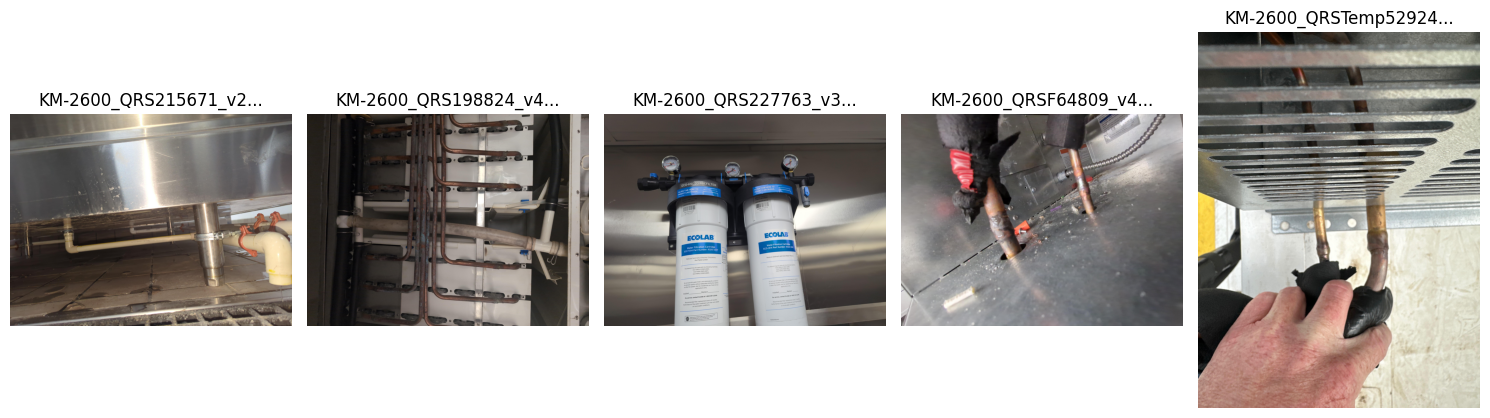

In [ ]:
from pathlib import Path
import random
from PIL import Image
import matplotlib.pyplot as plt

image_dir = Path('/content/drop_zone_training/drop_zone_training/noise/')

if not image_dir.is_dir():
    print(f"Error: Directory {image_dir} does not exist.")
else:
    all_files = [f for f in image_dir.rglob('*') if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f"Found {len(all_files)} image files in {image_dir}")

    if len(all_files) > 0:
        # Select up to 5 random images to display
        sample_images = random.sample(all_files, min(len(all_files), 5))

        plt.figure(figsize=(15, 5))
        for i, img_path in enumerate(sample_images):
            try:
                img = Image.open(img_path)
                plt.subplot(1, len(sample_images), i + 1)
                plt.imshow(img)
                plt.title(img_path.name[:20] + '...') # Show first 20 chars of filename
                plt.axis('off')
            except Exception as e:
                print(f"Could not open image {img_path}: {e}")
        plt.tight_layout()
        plt.show()
    else:
        print("No image files found in the directory.")


              precision    recall  f1-score   support

   drop_zone       0.81      1.00      0.90        48
       noise       1.00      0.97      0.98       345

    accuracy                           0.97       393
   macro avg       0.91      0.98      0.94       393
weighted avg       0.98      0.97      0.97       393



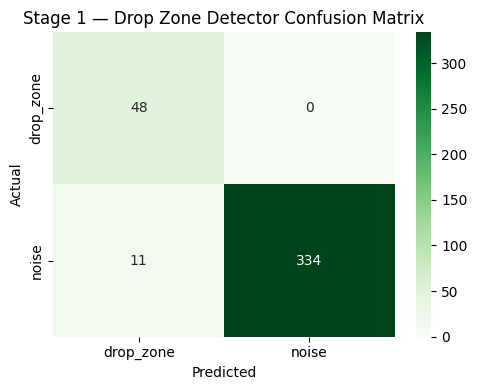

Saved: drop_zone_detector.pt  (val_acc=0.972)


In [ ]:
# Cell 5 — Evaluate and save Stage 1 detector
detector.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in det_val_loader:
        preds = detector(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=det_val_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=det_val_ds.classes, yticklabels=det_val_ds.classes, cmap='Greens')
plt.title('Stage 1 — Drop Zone Detector Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('dz_detector_confusion.png', dpi=150)
plt.show()

det_bundle = {
    'model_state_dict': detector.state_dict(),
    'class_to_idx':     det_train_ds.class_to_idx,
    'idx_to_class':     {v: k for k, v in det_train_ds.class_to_idx.items()},
    'dz_class_idx':     DZ_IDX,
    'architecture':     'efficientnet_b0',
    'input_size':       IMG_SIZE,
    'val_acc':          round(max(acc1, acc2), 4),
    'version':          1,
}
torch.save(det_bundle, 'drop_zone_detector.pt')
shutil.copy('drop_zone_detector.pt', MODEL_OUT / 'drop_zone_detector.pt')
print(f'Saved: drop_zone_detector.pt  (val_acc={det_bundle["val_acc"]})')

In [ ]:
# Cell 6 — Stage 2 choice
# ─────────────────────────────────────────────────────────────────────────────
# OPTION A (default): Supervised EfficientNet B0 binary classifier
#   Requires: 30+ labeled bad photos
#   Pros: learns BOTH good and bad explicitly — far more accurate than IF
#   Output: drop_zone_quality.pt
#
# OPTION B: DINOv2 + Isolation Forest (one-class)
#   Use only if you have fewer than 30 bad photos
#   Pros: works with very few bad examples
#   Cons: only learns "good" — misses defects that look visually similar to good
#   Output: drop_zone_model.pkl
# ─────────────────────────────────────────────────────────────────────────────

# Hardcoded to supervised — you have labeled bad photos and a binary classifier
# is strictly better than Isolation Forest when you have both classes.
# Change to False only if you want to experiment with the IF fallback.
USE_SUPERVISED = True
if len(bad_paths) < 20:
    print(f'\u26a0 Only {len(bad_paths)} bad photos — supervised mode may overfit. '
          'Add more bad photos or consider the IF fallback.')
elif len(bad_paths) < 30:
    print(f'\u26a0 {len(bad_paths)} bad photos — marginal. More is better for Stage 2.')

print(f'Bad photos available : {len(bad_paths)}')
print(f'Stage 2 mode         : {"Supervised EfficientNet B0" if USE_SUPERVISED else "DINOv2 + Isolation Forest"}')
if not USE_SUPERVISED:
    print('  (add more bad photos to reach 30+ and unlock supervised mode)')

Bad photos available : 31
Stage 2 mode         : Supervised EfficientNet B0


In [ ]:
import torch.nn.functional as F
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedKFold
from collections import defaultdict

# Defining USE_SUPERVISED locally to ensure it's available in this cell
# This value reflects the choice made and confirmed by the output of the previous cell (nc4tA8NLZfLh)
USE_SUPERVISED = True

if USE_SUPERVISED:
    # ── Helpers ───────────────────────────────────────────────────────────────
    CLASS_TO_IDX = {'defect': 0, 'good': 1}   # alphabetical ImageFolder order
    IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
    DEFECT_IDX   = CLASS_TO_IDX['defect']
    NUM_CLASSES  = 2

    class FileListDataset(Dataset):
        def __init__(self, pairs, transform):
            self.pairs = [(str(p), l) for p, l in pairs]
            self.transform = transform
        def __len__(self): return len(self.pairs)
        def __getitem__(self, idx):
            path, label = self.pairs[idx]
            img = Image.open(path).convert('RGB')
            return self.transform(img), label

    def mixup_batch(imgs, labels, num_classes, alpha=0.4):
        lam    = float(np.random.beta(alpha, alpha))
        idx    = torch.randperm(imgs.size(0), device=imgs.device)
        mixed  = lam * imgs + (1 - lam) * imgs[idx]
        oh     = F.one_hot(labels, num_classes).float()
        soft_y = lam * oh + (1 - lam) * oh[idx]
        return mixed, soft_y

    def train_fold(model, train_loader, val_loader, epochs, lr,
                   unfreeze_blocks=None, use_mixup=True):
        if unfreeze_blocks:
            for name, param in model.named_parameters():
                if any(b in name for b in unfreeze_blocks) or 'classifier' in name:
                    param.requires_grad = True
        params    = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = optim.Adam(params, lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        best_acc, best_state = 0, None
        for epoch in range(1, epochs + 1):
            model.train()
            tr_correct, tr_total = 0, 0
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                if use_mixup:
                    mixed, soft_y = mixup_batch(imgs, labels, NUM_CLASSES)
                    out  = model(mixed)
                    loss = -(soft_y * F.log_softmax(out, dim=1)).sum(1).mean()
                else:
                    out  = model(imgs)
                    loss = criterion(out, labels)
                loss.backward()
                optimizer.step()
                tr_correct += (out.argmax(1) == labels).sum().item()
                tr_total   += len(imgs)
            model.eval()
            vl_correct, vl_total = 0, 0
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    vl_correct += (model(imgs).argmax(1) == labels).sum().item()
                    vl_total   += len(imgs)
            vl_acc = vl_correct / max(1, vl_total)
            scheduler.step()
            flag = ''
            if vl_acc > best_acc:
                best_acc   = vl_acc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                flag = '  ← saved'
            print(f'  Ep {epoch:2d} | train={tr_correct/max(1,tr_total):.3f} | val={vl_acc:.3f}{flag}')
        model.load_state_dict(best_state)
        return best_acc

    # ── Augment originals (5x cap) ────────────────────────────────────────────
    aug_tf = T.Compose([
        T.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
        T.RandomRotation(15),
        T.RandomPerspective(distortion_scale=0.25, p=0.4),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    ])

    def augment_paths(orig_paths, label, target, aug_dir, max_mult=5):
        aug_dir.mkdir(parents=True, exist_ok=True)
        result = [(p, label) for p in orig_paths]
        cap    = min(target, len(orig_paths) * max_mult)
        needed = cap - len(orig_paths)
        if needed <= 0:
            return result
        aug_per = max(1, needed // max(1, len(orig_paths))) + 1
        added   = []
        for orig in orig_paths:
            img = Image.open(orig).convert('RGB')
            for j in range(aug_per):
                out = aug_dir / f'{orig.stem}_aug{j:03d}{orig.suffix}'
                aug_tf(img).save(out)
                added.append((out, label))
                if len(added) >= needed: break
            if len(added) >= needed: break
        result.extend(added)
        return result

    target = max(len(good_paths), len(bad_paths))
    aug_good_dir = Path('dz_aug_good')
    aug_bad_dir  = Path('dz_aug_bad')
    aug_good_pairs = augment_paths(good_paths, CLASS_TO_IDX['good'],   target, aug_good_dir)
    aug_bad_pairs  = augment_paths(bad_paths,  CLASS_TO_IDX['defect'], target, aug_bad_dir)

    print(f'Augmented — good: {len(aug_good_pairs)}  bad/defect: {len(aug_bad_pairs)}')
    print(f'(bad originals: {len(bad_paths)}  cap: {len(bad_paths)*5}  target: {target})')

    # ── K-Fold training ───────────────────────────────────────────────────────
    all_aug_pairs = aug_good_pairs + aug_bad_pairs

    # Aug index: orig_stem → [(aug_path, label), ...]
    aug_index = defaultdict(list)
    for p, l in all_aug_pairs:
        stem = Path(p).stem if not isinstance(p, Path) else p.stem
        orig_stem = stem.rsplit('_aug', 1)[0] if '_aug' in stem else stem
        aug_index[orig_stem].append((p, l))

    orig_pairs  = ([(p, CLASS_TO_IDX['good'])   for p in good_paths] +
                   [(p, CLASS_TO_IDX['defect']) for p in bad_paths])
    orig_labels = [l for _, l in orig_pairs]

    qual_train_tf = T.Compose([
        T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        T.RandomRotation(15),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    N_FOLDS = 5
    skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    fold_state_dicts = []
    fold_val_accs    = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(orig_pairs, orig_labels)):
        print(f'\n{"="*50}')
        print(f'FOLD {fold+1}/{N_FOLDS}')

        val_pairs  = [orig_pairs[i] for i in val_idx]
        val_stems  = {Path(p).stem for p, _ in val_pairs}

        train_pairs = [(p, l) for stem, entries in aug_index.items()
                               if stem not in val_stems
                               for p, l in entries]

        tr_counts = defaultdict(int)
        vl_counts = defaultdict(int)
        for _, l in train_pairs: tr_counts[IDX_TO_CLASS[l]] += 1
        for _, l in val_pairs:   vl_counts[IDX_TO_CLASS[l]] += 1
        print(f'  Train: {dict(tr_counts)}')
        print(f'  Val  : {dict(vl_counts)}')

        train_ds = FileListDataset(train_pairs, qual_train_tf)
        val_ds   = FileListDataset(val_pairs,   INFERENCE_TF)

        tr_lbls = [l for _, l in train_pairs]
        counts  = Counter(tr_lbls)
        wts     = [1.0 / counts[l] for l in tr_lbls]
        sampler = WeightedRandomSampler(wts, num_samples=len(wts), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers=2)
        val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,   num_workers=2)

        model = make_efficientnet(num_classes=NUM_CLASSES)
        print(f'  Phase 1 — head only (12 epochs, mixup=ON)')
        acc1 = train_fold(model, train_loader, val_loader, epochs=12, lr=1e-3, use_mixup=True)
        print(f'  Phase 2 — fine-tune (12 epochs, mixup=ON)')
        acc2 = train_fold(model, train_loader, val_loader, epochs=12, lr=5e-5,
                          unfreeze_blocks=['features.6', 'features.7', 'features.8'],
                          use_mixup=True)
        best = max(acc1, acc2)
        fold_state_dicts.append({k: v.clone() for k, v in model.state_dict().items()})
        fold_val_accs.append(best)
        print(f'  Fold {fold+1} best val acc: {best:.3f}')

        # --- Save a checkpoint after each fold --- NEW
        checkpoint_bundle = {
            'fold_state_dicts': fold_state_dicts,
            'fold_val_accs': fold_val_accs,
            'completed_folds': fold + 1,
            'N_FOLDS': N_FOLDS,
            'CLASS_TO_IDX': CLASS_TO_IDX,
            'IDX_TO_CLASS': IDX_TO_CLASS,
            'defect_class_idx': DEFECT_IDX,
            'architecture': 'efficientnet_b0',
            'input_size': IMG_SIZE,
            'good_count': len(good_paths),
            'bad_count': len(bad_paths),
            'version': 2.1, # Indicating a checkpoint version
        }
        checkpoint_path = MODEL_OUT / f'drop_zone_quality_checkpoint_fold{fold+1}.pt'
        torch.save(checkpoint_bundle, checkpoint_path)
        print(f'  Saved checkpoint for fold {fold+1} to {checkpoint_path}')

    print(f'\n{"="*50}')
    print(f'K-Fold complete:')
    for i, acc in enumerate(fold_val_accs):
        print(f'  Fold {i+1}: {acc:.3f}')
    print(f'Mean : {np.mean(fold_val_accs):.3f}  ±  {np.std(fold_val_accs):.3f}')

else:
    # ── DINOv2 + Isolation Forest fallback (unchanged) ────────────────────────
    print('Loading DINOv2-small for Isolation Forest training...')
    dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False)
    dino.eval().to(DEVICE)

    def extract_emb(path):
        try:
            img = Image.open(path).convert('RGB')
            t = DINO_TF(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                return dino(t).squeeze().cpu().numpy()
        except: return None

    X_good = np.array([e for p in good_paths if (e := extract_emb(p)) is not None])
    X_bad  = np.array([e for p in bad_paths  if (e := extract_emb(p)) is not None])
    print(f'Good embeddings: {len(X_good)}  Bad embeddings: {len(X_bad)}')


Augmented — good: 282  bad/defect: 155
(bad originals: 31  cap: 155  target: 282)

FOLD 1/5
  Train: {'good': 225, 'defect': 135}
  Val  : {'good': 57, 'defect': 6}
  Phase 1 — head only (12 epochs, mixup=ON)
  Ep  1 | train=0.614 | val=0.841  ← saved
  Ep  2 | train=0.775 | val=0.921  ← saved
  Ep  3 | train=0.719 | val=0.921
  Ep  4 | train=0.589 | val=0.921
  Ep  5 | train=0.772 | val=0.921
  Ep  6 | train=0.753 | val=0.921
  Ep  7 | train=0.775 | val=0.921
  Ep  8 | train=0.722 | val=0.921
  Ep  9 | train=0.711 | val=0.921
  Ep 10 | train=0.678 | val=0.921
  Ep 11 | train=0.758 | val=0.921
  Ep 12 | train=0.736 | val=0.921
  Phase 2 — fine-tune (12 epochs, mixup=ON)
  Ep  1 | train=0.742 | val=0.921  ← saved
  Ep  2 | train=0.725 | val=0.921
  Ep  3 | train=0.800 | val=0.921
  Ep  4 | train=0.689 | val=0.921
  Ep  5 | train=0.658 | val=0.921
  Ep  6 | train=0.803 | val=0.921
  Ep  7 | train=0.683 | val=0.921
  Ep  8 | train=0.708 | val=0.921
  Ep  9 | train=0.708 | val=0.921
  Ep 1

In [ ]:
# Cell 8 — Calibrate threshold
if USE_SUPERVISED:
    # Build ensemble
    ensemble_nets = []
    for sd in fold_state_dicts:
        net = make_efficientnet(num_classes=NUM_CLASSES)
        net.load_state_dict(sd)
        net.eval().to(DEVICE)
        ensemble_nets.append(net)

    # Score ALL originals with ensemble (out-of-fold gives unbiased threshold)
    all_orig_ds     = FileListDataset(orig_pairs, INFERENCE_TF)
    all_orig_loader = DataLoader(all_orig_ds, batch_size=16, shuffle=False, num_workers=2)

    defect_probs_good = []
    defect_probs_bad  = []

    with torch.no_grad():
        for imgs, labels in all_orig_loader:
            imgs = imgs.to(DEVICE)
            probs_avg = sum(
                torch.softmax(net(imgs), dim=1) for net in ensemble_nets
            ) / N_FOLDS
            defect_probs = probs_avg[:, DEFECT_IDX].cpu().numpy()
            for p, l in zip(defect_probs, labels.numpy()):
                if l == CLASS_TO_IDX['good']:
                    defect_probs_good.append(p)
                else:
                    defect_probs_bad.append(p)

    median_good = float(np.median(defect_probs_good))
    median_bad  = float(np.median(defect_probs_bad))
    threshold   = round((median_good + median_bad) / 2, 4)

    print(f'Good defect-prob (median) : {median_good:.4f}')
    print(f'Bad  defect-prob (median) : {median_bad:.4f}')
    print(f'Calibrated threshold      : {threshold:.4f}  (midpoint)')
    print(f'  Defects caught  : {sum(1 for p in defect_probs_bad  if p >= threshold)}/{len(defect_probs_bad)}')
    print(f'  False positives : {sum(1 for p in defect_probs_good if p >= threshold)}/{len(defect_probs_good)}')
    print()
    print('Tip: lower threshold → catch more defects (more false positives).')
    print('     raise threshold → fewer false positives (might miss subtle defects).')

    plt.figure(figsize=(10, 5))
    plt.hist(defect_probs_good, bins=30, alpha=0.6, color='green', label=f'Good ({len(defect_probs_good)})')
    plt.hist(defect_probs_bad,  bins=20, alpha=0.7, color='red',   label=f'Bad ({len(defect_probs_bad)})')
    plt.axvline(threshold,   color='black', linestyle='--', linewidth=2,   label=f'Threshold = {threshold:.4f}')
    plt.axvline(median_good, color='green', linestyle=':',  linewidth=1.5, label=f'Good median = {median_good:.4f}')
    plt.axvline(median_bad,  color='red',   linestyle=':',  linewidth=1.5, label=f'Bad median = {median_bad:.4f}')
    plt.xlabel('Defect Probability')
    plt.ylabel('Count')
    plt.title('Drop Zone Stage 2 (Ensemble) — Score Distribution')
    plt.legend()
    plt.tight_layout()
    plt.savefig('dz_threshold.png', dpi=150)
    plt.show()

else:
    print(f'Training Isolation Forest on {len(X_good)} good embeddings...')
    clf = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
    clf.fit(X_good)
    good_scores = clf.decision_function(X_good)
    bad_scores  = clf.decision_function(X_bad)
    print(f'Good score range : {good_scores.min():.4f} – {good_scores.max():.4f}')
    print(f'Bad  score range : {bad_scores.min():.4f}  – {bad_scores.max():.4f}')
    print('\nBad photo scores:')
    for path, score in sorted(zip(bad_paths, bad_scores), key=lambda x: x[1]):
        flag = 'FLAGGED' if score < 0 else 'MISSED'
        print(f'  {score:.4f}  [{flag}]  {path.name}')
    bad_median = float(np.median(bad_scores))
    bad_worst  = float(bad_scores.min())
    threshold  = bad_median * 1.05
    print(f'\nCalibrated threshold : {threshold:.4f}  (median-based)')
    print(f'  Bad caught   : {sum(1 for s in bad_scores  if s < threshold)}/{len(bad_scores)}')
    print(f'  Good flagged : {sum(1 for s in good_scores if s < threshold)}/{len(good_scores)}')
    plt.figure(figsize=(10, 5))
    plt.hist(good_scores, bins=40, alpha=0.6, color='green', label=f'Good ({len(good_scores)})')
    plt.hist(bad_scores,  bins=20, alpha=0.7, color='red',   label=f'Bad ({len(bad_scores)})')
    plt.axvline(threshold, color='black',  linestyle='--', linewidth=2,   label=f'Threshold = {threshold:.4f}')
    plt.axvline(bad_worst, color='orange', linestyle=':',  linewidth=1.5, label=f'Worst bad = {bad_worst:.4f}')
    plt.axvline(0,         color='gray',   linestyle=':',  linewidth=1,   label='IF boundary (0)')
    plt.xlabel('Isolation Forest Score'); plt.ylabel('Count')
    plt.title('Drop Zone Stage 2 (IF) — Score Distribution')
    plt.legend(); plt.tight_layout()
    plt.savefig('dz_threshold.png', dpi=150); plt.show()


In [ ]:
# Cell 9 — Save Stage 2 model + download both models
if USE_SUPERVISED:
    quality_bundle = {
        'fold_state_dicts': fold_state_dicts,
        'class_to_idx':     CLASS_TO_IDX,
        'idx_to_class':     IDX_TO_CLASS,
        'defect_class_idx': DEFECT_IDX,
        'architecture':     'efficientnet_b0',
        'input_size':       IMG_SIZE,
        'threshold':        threshold,
        'good_count':       len(good_paths),
        'bad_count':        len(bad_paths),
        'k_folds':          N_FOLDS,
        'fold_val_accs':    fold_val_accs,
        'mean_val_acc':     round(float(np.mean(fold_val_accs)), 4),
        'version':          2,
    }
    quality_path = 'drop_zone_quality.pt'
    torch.save(quality_bundle, quality_path)
    shutil.copy(quality_path,       MODEL_OUT / quality_path)
    shutil.copy('dz_threshold.png', MODEL_OUT / 'dz_threshold.png')
    print(f'Stage 2 [ensemble {N_FOLDS}-fold] saved: {quality_path}')
    print(f'  good_count    : {quality_bundle["good_count"]}')
    print(f'  bad_count     : {quality_bundle["bad_count"]}')
    print(f'  mean_val_acc  : {quality_bundle["mean_val_acc"]}')
    print(f'  fold_val_accs : {[round(a,3) for a in fold_val_accs]}')
    print(f'  threshold     : {quality_bundle["threshold"]:.4f}')
else:
    quality_bundle = {
        'clf':              clf,
        'threshold':        threshold,
        'good_count':       len(X_good),
        'bad_count':        len(X_bad),
        'dinov2_model':     'dinov2_vits14',
        'good_score_range': (float(good_scores.min()), float(good_scores.max())),
        'bad_score_range':  (float(bad_scores.min()),  float(bad_scores.max())),
    }
    quality_path = 'drop_zone_model.pkl'
    with open(quality_path, 'wb') as f:
        pickle.dump(quality_bundle, f)
    shutil.copy(quality_path,       MODEL_OUT / quality_path)
    shutil.copy('dz_threshold.png', MODEL_OUT / 'dz_threshold.png')
    print(f'Stage 2 [isolation_forest] saved: {quality_path}')
    print(f'  threshold  : {quality_bundle["threshold"]:.4f}')

print('\n' + '='*60)
print('Downloading both models...')
from google.colab import files
files.download('drop_zone_detector.pt')
files.download(quality_path)
files.download('dz_threshold.png')
print('\nNext steps:')
print(f'  1. Drop drop_zone_detector.pt into  drop_zone-model/')
if USE_SUPERVISED:
    print(f'  2. Drop drop_zone_quality.pt  into  drop_zone-model/')
else:
    print(f'  2. Drop drop_zone_model.pkl   into  drop_zone-model/')
print(f'  3. Run: python3 run_drop_zone_report.py')
